# Causality-Aware Market Regime Detection

This Notebook implements the initial stage of a research project on
market regime detection using rule-based logic and interpretable
machine learning models.

Author: Param Patel  
Status: Conference-style research prototype


## 1. Introduction & Motivation
## 2. Data & Feature Engineering
## 3. Rule-Based Causal Regime Detection
## 4. Machine Learning Regime Classification
## 5. Evaluation & Interpretation
## 6. Key Takeaways & Limitations

### Key Takeaways

- Rule-based logic provides economically interpretable regime definitions.
- Logistic regression successfully learns probabilistic regime boundaries.
- High-volatility regimes are detected with high reliability.
- Range-bound regimes show expected ambiguity during transitions.
- The hybrid framework balances interpretability and adaptability.


### Limitations

- Regime labels are derived from rule-based heuristics rather than ground truth.
- The study focuses on interpretability rather than trading profitability.
- Causal relationships are conceptual and not formally identified using SCMs.
- Future work may include state-space or regime-switching models.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("default")


In [2]:
data = yf.download(
    "^GSPC",
    start="2015-01-01",
    auto_adjust=True,
    progress=False
)

# Keep only required columns
data = data[["Close", "Volume"]]
data.columns = ["price", "volume"]

In [3]:
data["returns"] = data["price"].pct_change()

data["volatility_20d"] = data["returns"].rolling(20).std()
data["volatility_60d"] = data["returns"].rolling(60).std()

data["trend_60d"] = data["price"].pct_change(60)

data.dropna(inplace=True)

In [4]:
def rule_based_regime(row):
    if row["volatility_20d"] > row["volatility_60d"] * 1.3:
        return "High Volatility"
    elif row["trend_60d"] > 0 and row["volatility_20d"] < row["volatility_60d"]:
        return "Trending"
    else:
        return "Range-Bound"

data["rule_regime"] = data.apply(rule_based_regime, axis=1)

print("Regime distribution:")
print(data["rule_regime"].value_counts())


Regime distribution:
rule_regime
Trending           1225
Range-Bound        1221
High Volatility     276
Name: count, dtype: int64


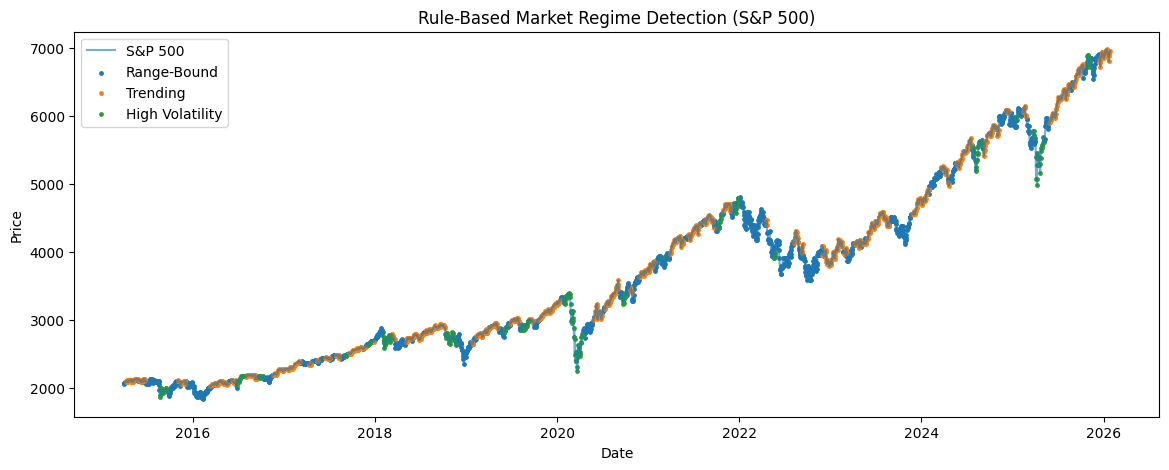

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(data.index, data["price"], label="S&P 500", alpha=0.6)

for regime in data["rule_regime"].unique():
    idx = data["rule_regime"] == regime
    plt.scatter(
        data.index[idx],
        data["price"][idx],
        label=regime,
        s=6
    )

plt.title("Rule-Based Market Regime Detection (S&P 500)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [7]:
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Features
features = ["volatility_20d", "volatility_60d", "trend_60d"]

X = data[features]
y = data["rule_regime"]

# Time-aware split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression (warning-free)
model = LogisticRegression(
    max_iter=500,
    solver="lbfgs"
)

model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
                 precision    recall  f1-score   support

High Volatility       1.00      0.85      0.92        61
    Range-Bound       0.70      0.81      0.75       335
       Trending       0.83      0.74      0.78       421

       accuracy                           0.78       817
      macro avg       0.84      0.80      0.82       817
   weighted avg       0.79      0.78      0.78       817



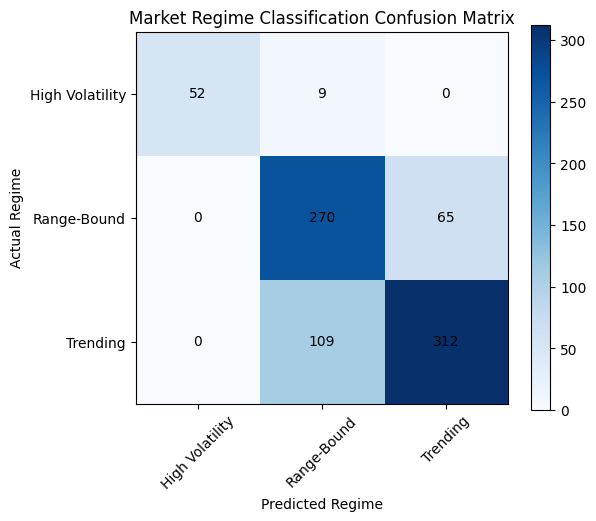

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(range(len(model.classes_)), model.classes_, rotation=45)
plt.yticks(range(len(model.classes_)), model.classes_)

for i in range(len(model.classes_)):
    for j in range(len(model.classes_)):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black")

plt.xlabel("Predicted Regime")
plt.ylabel("Actual Regime")
plt.title("Market Regime Classification Confusion Matrix")
plt.show()


In [9]:
# ==============================
# Add NIFTY 50 Data (India)
# ==============================

data_nifty = yf.download(
    "^NSEI",
    start="2015-01-01",
    auto_adjust=True,
    progress=False
)

data_nifty = data_nifty[["Close", "Volume"]]
data_nifty.columns = ["price", "volume"]

# Feature engineering (same as S&P 500)
data_nifty["returns"] = data_nifty["price"].pct_change()

data_nifty["volatility_20d"] = data_nifty["returns"].rolling(20).std()
data_nifty["volatility_60d"] = data_nifty["returns"].rolling(60).std()

data_nifty["trend_60d"] = data_nifty["price"].pct_change(60)

data_nifty.dropna(inplace=True)

data_nifty.head()


,price,volume,returns,volatility_20d,volatility_60d,trend_60d
Date,,,,,,
2015-04-01,8586.250000,125500,0.011218,0.009904,0.010126,0.022727
2015-04-06,8659.900391,146900,0.008578,0.010086,0.010174,0.033598
2015-04-07,8660.299805,148700,0.000046,0.010066,0.009351,0.065575
2015-04-08,8714.400391,148200,0.006247,0.009176,0.009357,0.075573
2015-04-09,8778.299805,152700,0.007333,0.009248,0.009181,0.066026


In [10]:
# Apply rule-based regimes to NIFTY 50
data_nifty["rule_regime"] = data_nifty.apply(rule_based_regime, axis=1)

print("NIFTY 50 Regime Distribution:")
print(data_nifty["rule_regime"].value_counts())


NIFTY 50 Regime Distribution:
rule_regime
Range-Bound        1394
Trending           1060
High Volatility     211
Name: count, dtype: int64


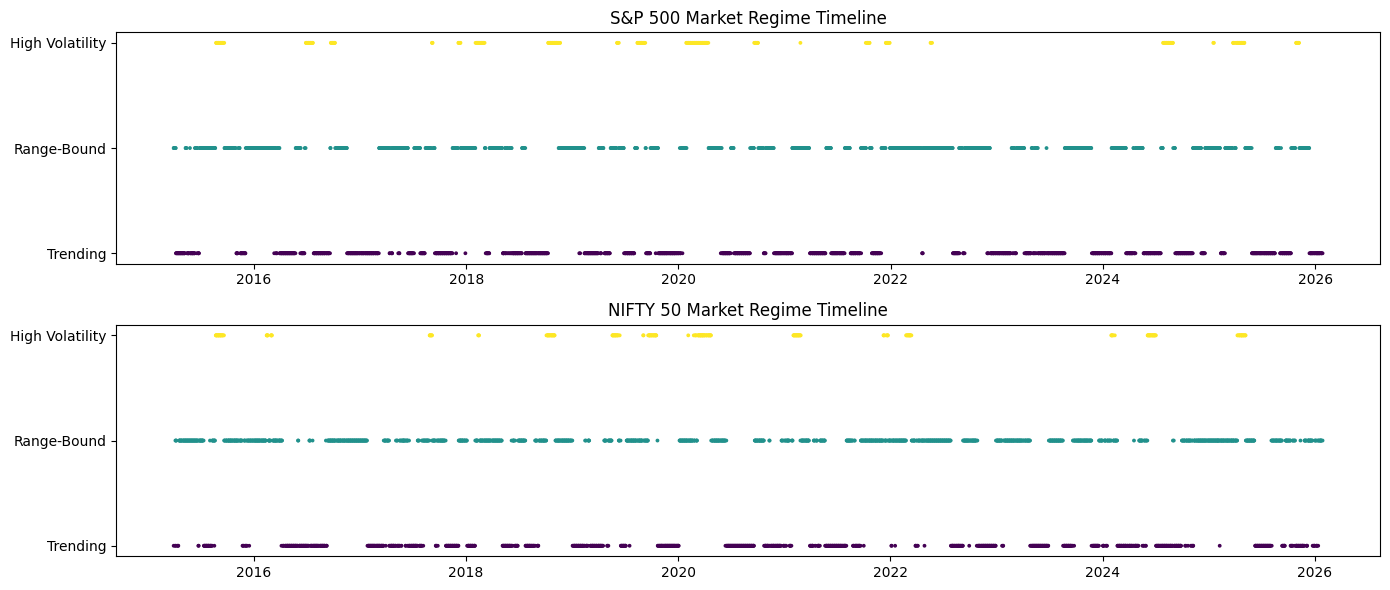

In [11]:
# ==============================
# Regime Timeline Plot
# ==============================

# Map regimes to numeric values for plotting
regime_map = {
    "Trending": 0,
    "Range-Bound": 1,
    "High Volatility": 2
}

# Apply mapping
data["regime_code"] = data["rule_regime"].map(regime_map)
data_nifty["regime_code"] = data_nifty["rule_regime"].map(regime_map)

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

# ----- S&P 500 Timeline -----
axes[0].scatter(
    data.index,
    data["regime_code"],
    c=data["regime_code"],
    cmap="viridis",
    s=3
)
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["Trending", "Range-Bound", "High Volatility"])
axes[0].set_title("S&P 500 Market Regime Timeline")

# ----- NIFTY 50 Timeline -----
axes[1].scatter(
    data_nifty.index,
    data_nifty["regime_code"],
    c=data_nifty["regime_code"],
    cmap="viridis",
    s=3
)
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(["Trending", "Range-Bound", "High Volatility"])
axes[1].set_title("NIFTY 50 Market Regime Timeline")

plt.tight_layout()
plt.show()


In [12]:
# ==============================
# ML Regime Probabilities (Same Pipeline)
# ==============================

# Features used in ML
features = ["volatility_20d", "volatility_60d", "trend_60d"]

# ---- S&P 500 probabilities ----
X_sp = data[features]
X_sp_scaled = scaler.transform(X_sp)
proba_sp = model.predict_proba(X_sp_scaled)

proba_sp_df = pd.DataFrame(
    proba_sp,
    index=data.index,
    columns=model.classes_
)

# ---- NIFTY 50 probabilities ----
X_nifty = data_nifty[features]
X_nifty_scaled = scaler.transform(X_nifty)
proba_nifty = model.predict_proba(X_nifty_scaled)

proba_nifty_df = pd.DataFrame(
    proba_nifty,
    index=data_nifty.index,
    columns=model.classes_
)

proba_sp_df.head(), proba_nifty_df.head()


(            High Volatility  Range-Bound  Trending
 Date                                              
 2015-03-31         0.027808     0.864220  0.107971
 2015-04-01         0.045287     0.821558  0.133155
 2015-04-02         0.054622     0.780464  0.164914
 2015-04-06         0.036163     0.775648  0.188188
 2015-04-07         0.052665     0.836383  0.110952,
             High Volatility  Range-Bound  Trending
 Date                                              
 2015-04-01         0.011105     0.825713  0.163182
 2015-04-06         0.013257     0.800307  0.186436
 2015-04-07         0.045260     0.686454  0.268286
 2015-04-08         0.012188     0.506806  0.481006
 2015-04-09         0.018923     0.589796  0.391281)

In [13]:
# ==============================
# Smooth Regime Probabilities
# ==============================

WINDOW = 30  # 30 trading days (~1.5 months)

proba_sp_smooth = proba_sp_df.rolling(WINDOW).mean()
proba_nifty_smooth = proba_nifty_df.rolling(WINDOW).mean()


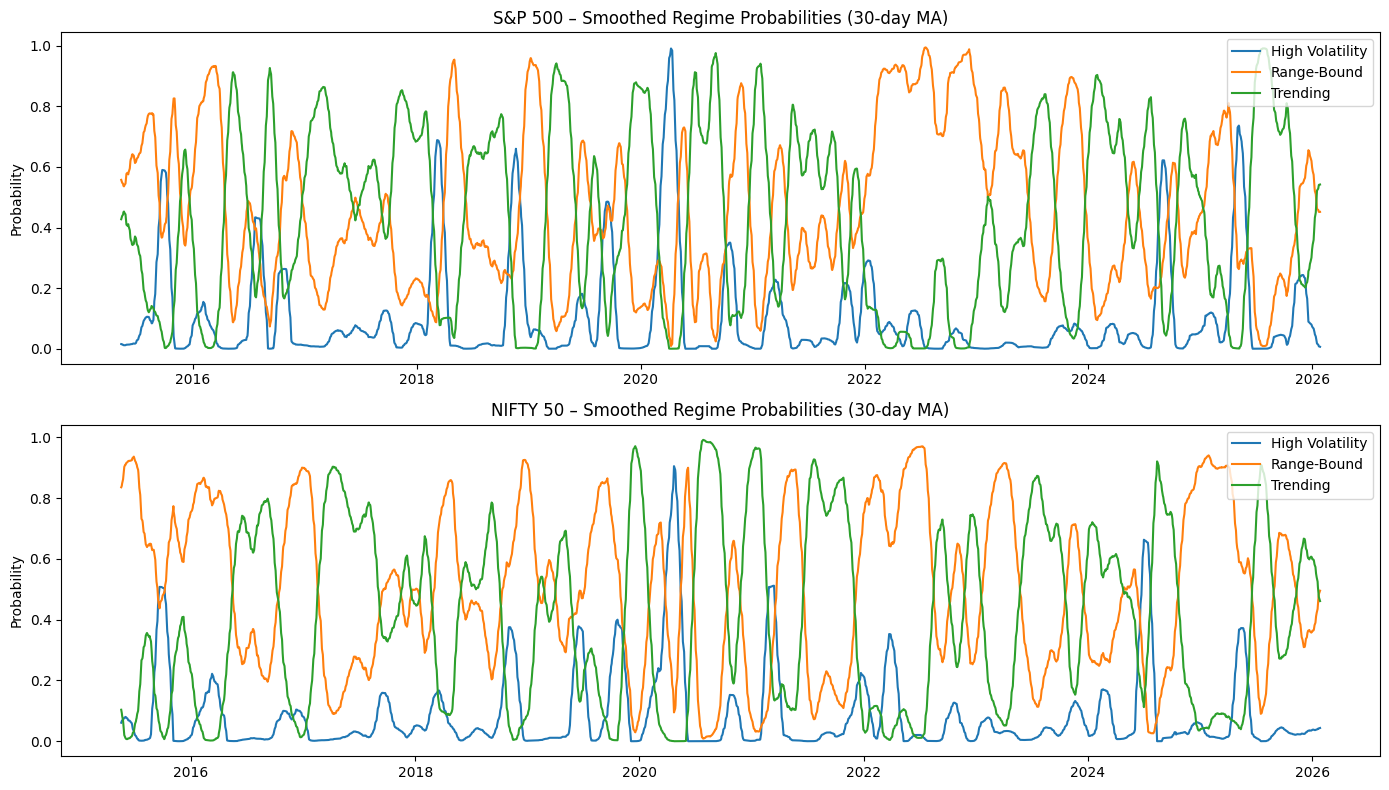

In [14]:
# ==============================
# Smoothed Probability Plots
# ==============================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# ---- S&P 500 ----
for regime in proba_sp_smooth.columns:
    axes[0].plot(
        proba_sp_smooth.index,
        proba_sp_smooth[regime],
        label=regime
    )

axes[0].set_title("S&P 500 – Smoothed Regime Probabilities (30-day MA)")
axes[0].set_ylabel("Probability")
axes[0].legend(loc="upper right")

# ---- NIFTY 50 ----
for regime in proba_nifty_smooth.columns:
    axes[1].plot(
        proba_nifty_smooth.index,
        proba_nifty_smooth[regime],
        label=regime
    )

axes[1].set_title("NIFTY 50 – Smoothed Regime Probabilities (30-day MA)")
axes[1].set_ylabel("Probability")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


In [15]:
import yfinance as yf
import pandas as pd

# ------------------------------
# Asset tickers
# ------------------------------
assets = {
    "Bitcoin": "BTC-USD",
    "Ethereum": "ETH-USD",
    "Solana": "SOL-USD",
    "XRP": "XRP-USD",
    "S&P500": "^GSPC",
    "NIFTY50": "^NSEI",
    "BANKNIFTY": "^NSEBANK"
}

start_date = "2017-01-01"  # covers crypto properly

price_data = []

# ------------------------------
# Download & clean each asset
# ------------------------------
for name, ticker in assets.items():
    df = yf.download(
        ticker,
        start=start_date,
        auto_adjust=True,
        progress=False
    )

    df = df[["Close"]]
    df.columns = [name]
    price_data.append(df)

# ------------------------------
# Merge into one big dataset
# ------------------------------
merged_prices = pd.concat(price_data, axis=1)

# Drop rows where ALL assets are missing
merged_prices.dropna(how="all", inplace=True)

merged_prices.head()

,Bitcoin,Ethereum,Solana,XRP,S&P500,NIFTY50,BANKNIFTY
Date,,,,,,,
2017-01-01,998.325012,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-02,1021.750000,NaN,NaN,NaN,NaN,8179.500000,NaN
2017-01-03,1043.839966,NaN,NaN,NaN,2257.830078,8192.250000,18035.390625
2017-01-04,1154.729980,NaN,NaN,NaN,2270.750000,8190.500000,17890.792969
2017-01-05,1013.380005,NaN,NaN,NaN,2269.000000,8273.799805,18115.738281


In [16]:
merged_prices.shape

(3314, 7)

In [17]:
merged_prices.index.min(), merged_prices.index.max()

(Timestamp('2017-01-01 00:00:00'), Timestamp('2026-01-27 00:00:00'))

In [18]:
merged_prices.tail()

,Bitcoin,Ethereum,Solana,XRP,S&P500,NIFTY50,BANKNIFTY
Date,,,,,,,
2026-01-23,89503.875000,2953.256348,127.361580,1.919532,6915.609863,25048.650391,58473.101562
2026-01-24,89110.734375,2948.740723,127.053818,1.913130,NaN,NaN,NaN
2026-01-25,86572.218750,2815.902344,118.772858,1.833026,NaN,NaN,NaN
2026-01-26,88267.140625,2926.457031,124.139725,1.903497,6950.229980,NaN,NaN
2026-01-27,88110.437500,2983.322021,125.141899,1.892956,NaN,25175.400391,59205.449219


In [19]:
for col in merged_prices.columns:
    print(col, "starts at:", merged_prices[col].first_valid_index())

Bitcoin starts at: 2017-01-01 00:00:00
Ethereum starts at: 2017-11-09 00:00:00
Solana starts at: 2020-04-10 00:00:00
XRP starts at: 2017-11-09 00:00:00
S&P500 starts at: 2017-01-03 00:00:00
NIFTY50 starts at: 2017-01-02 00:00:00
BANKNIFTY starts at: 2017-01-03 00:00:00


In [20]:
merged_prices.shape

(3314, 7)

In [ ]:
features = ["volatility_20d", "volatility_60d", "trend_60d"]

X = data[features]
y = data["rule_regime"]

: 